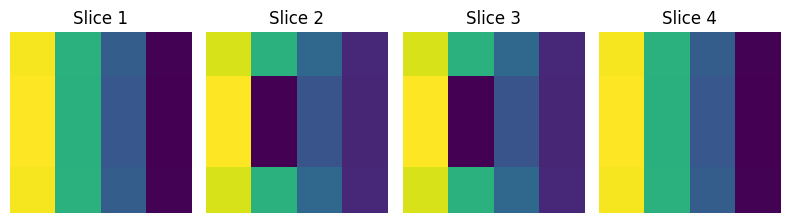

[[-5.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,0.0 ,1.0 ,-5.0 ,0.

C:\Users\Rafael\AppData\Local\Temp\ipykernel_57520\4099190374.py:17: RuntimeWarning: overflow encountered in cast
  residuals[row] = residual


In [1]:
%run darcy_solver.ipynb

In [2]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [3]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [4]:
import porespy as ps

In [5]:
vol = ps.generators.blobs(shape=(20, 20, 20), blobiness=0.4, porosity=0.55)

In [6]:
import numpy as np
import scipy as sc

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
print(np.unique(lab[0,:,:]))
print(np.unique(lab[-1,:,:]))
print(np.unique(lab[:,0,:]))
print(np.unique(lab[:,-1,:]))
print(np.unique(lab[:,:,0]))
print(np.unique(lab[:,:,-1]))

[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1 2]


In [9]:
con_vol = (lab==1)*100 #porosity map ndarray unit8 0..100

In [10]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [11]:
volume_manager = VolumeManager(con_vol)

In [12]:
sparse_A, sparse_b = volume_manager.get_sparse_system()

In [ ]:
solver = DarcySolver()
solution = solver.solve(sparse_A, sparse_b)
raveled_solution = volume_manager.ravel_sparse_solution(solution)

[9.9795884e-01 9.9696249e-01 9.9692130e-01 ... 1.0322134e-03 1.0719787e-03
 5.0778064e-05] 0.125 1.1544305580755918 inf
[9.9545801e-01 9.9365860e-01 9.9371678e-01 ... 1.7590747e-03 2.0453865e-03
 1.7053036e-04] 0.15625 0.992760723432615 1.1544305580755918
[9.9265909e-01 9.9012744e-01 9.9015510e-01 ... 2.5845557e-03 3.0574987e-03
 3.7063612e-04] 0.1796875 0.8374399625600156 0.992760723432615
[9.8968703e-01 9.8653793e-01 9.8640007e-01 ... 3.4740479e-03 4.0571857e-03
 6.4542185e-04] 0.197265625 0.6978968577280594 0.8374399625600156
[9.866348e-01 9.829888e-01 9.825717e-01 ... 4.400437e-03 5.018912e-03
 9.789045e-04] 0.21044921875 0.5776610346764739 0.6978968577280594
[0.98356813 0.97953236 0.97875464 ... 0.00534343 0.00593308 0.0013518 ] 0.2203369140625 0.4767690218149844 0.5776610346764739
[0.9805313  0.9761932  0.97500557 ... 0.00628853 0.00679873 0.0017462 ] 0.227752685546875 0.39349943146528865 0.4767690218149844
[0.9775522  0.97298    0.9713604  ... 0.00722587 0.007619   0.00214775] 0

In [29]:
import matplotlib.pyplot as plt

def plt_show(img, samples):
    num_slices = raveled_solution.shape[2]
    fig, axs = plt.subplots(3, samples+1, figsize=(8, 8))
    
    for i in range(num_slices//samples):
        slice_2d = img[i*samples, :, :]
        axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[0,i].set_title(f'Slice {i + 1}')
        axs[0,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, i*samples, :]
        axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[1,i].set_title(f'Slice {i + 1 + 4}')
        axs[1,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, :, i*samples]
        axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[2,i].set_title(f'Slice {i + 1 + 4}')
        axs[2,i].axis('off')  # Turn off axis for better visualization
    
    plt.tight_layout()
    plt.show()

0.0 0.9999266


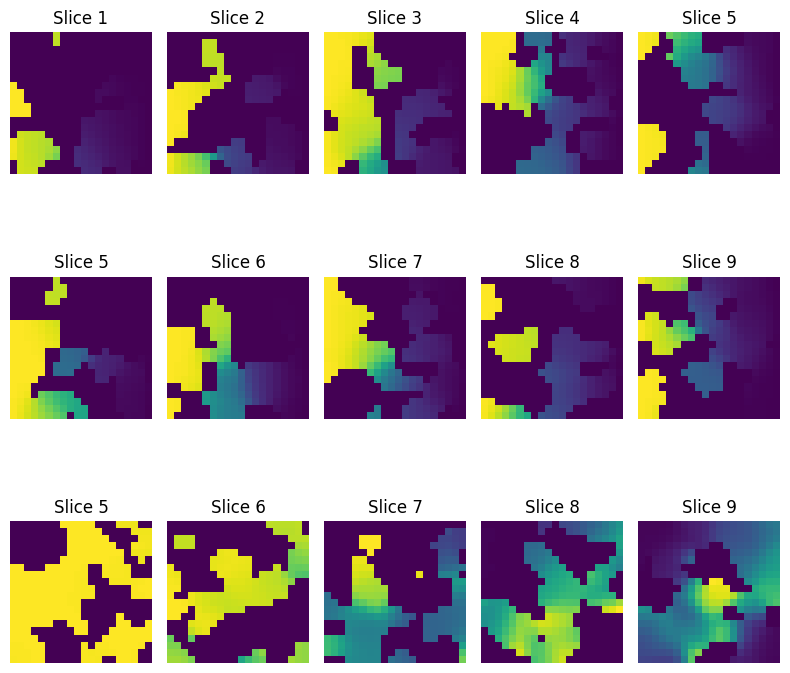

In [45]:
print(raveled_solution.min(), raveled_solution.max())
plt_show(raveled_solution, 4)

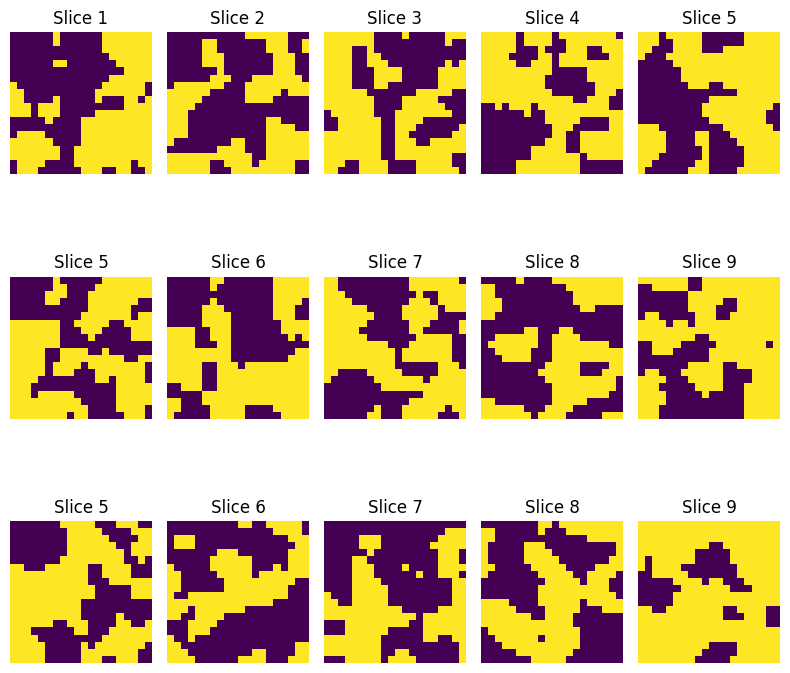

In [31]:
plt_show(vol, 4)

In [37]:
print(con_vol.min(), con_vol.max())
print(pressure_field[0, :, :].mean())
print(pressure_field[-1, :, :].mean())
print(pressure_field[:, 0, :].mean())
print(pressure_field[:, -1, :].mean())
print(pressure_field[:, :, 0].mean())
print(pressure_field[:, :, -1].mean())

0.0 20.170599
0.11339037
0.21797691
0.25111377
0.2096033
0.57495
0.0025292796


In [42]:
pressure_field = raveled_solution
x_pressure_gradient = np.zeros_like(pressure_field)
x_pressure_gradient[1:, :, :] -= x_pressure_gradient[:-1, :, :]
x_conductance = np.zeros_like(pressure_field)
x_conductance[1:, :, :] = 2/ (1/x_conductance[1:, :, :] + 1/x_conductance[:-1, :, :])
x_speed = x_pressure_gradient * x_conductance

0.0 0.0


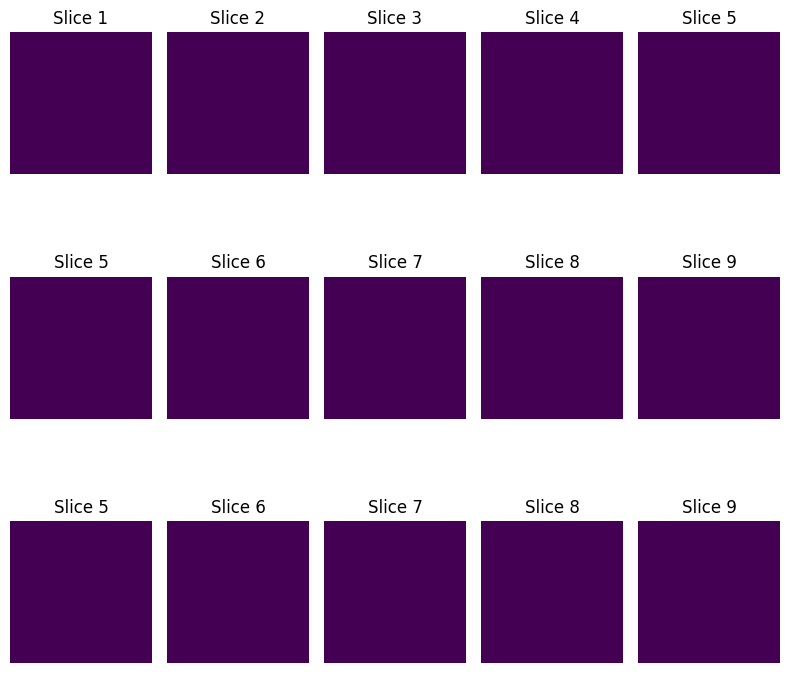

In [44]:
print(x_speed.min(), x_speed.max())
plt_show(x_speed, 4)

In [10]:
ps.__dict__

{'__name__': 'porespy',
 '__doc__': None,
 '__package__': 'porespy',
 '__loader__': <_frozen_importlib_external._NamespaceLoader at 0x2208539f520>,
 '__spec__': ModuleSpec(name='porespy', loader=<_frozen_importlib_external._NamespaceLoader object at 0x000002208539F520>, submodule_search_locations=_NamespacePath(['d:\\geoslicer\\slicerltrace\\src\\submodules\\porespy\\porespy'])),
 '__file__': None,
 '__path__': _NamespacePath(['d:\\geoslicer\\slicerltrace\\src\\submodules\\porespy\\porespy'])}